# 1: Initialisation

In [1]:
# Imports
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#plt.style.use('seaborn-v0_8')

# Pre-processing tools
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer

# Data splitting
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Model analysis
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Alpha cross validation
from sklearn.linear_model import RidgeCV, LassoCV

In [2]:
# Load datasets

train_frame = pd.read_csv('./dataset/train_data.csv')
unknown_frame = pd.read_csv('./dataset/test_data.csv')

# 'test_data' will not be used as initial test data, as we cannot supervise learning
# Test data will be obtained from splitting the training dataset

# 2: Exploratory Data Analysis (EDA)

In [3]:
# Initial View

# print(train_frame)
# train_frame.shape
# train_frame.info()
train_frame.describe()
# train_frame.head(10)

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,calculated_host_listings_count
count,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000
mean,-37.825074,145.009374,3.559865,1.282320,1.533077,2.036222,139.771372,3.158747,27.946657,94.176101,7.427324
std,0.065145,0.130473,2.225801,0.557906,0.916369,1.544967,123.293376,20.788007,42.409812,8.471527,15.438001
min,-38.224427,144.531993,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,20.000000,1.000000
25%,-37.849202,144.957065,2.000000,1.000000,1.000000,1.000000,71.000000,1.000000,3.000000,92.000000,1.000000
50%,-37.816460,144.977004,3.000000,1.000000,1.000000,2.000000,115.000000,2.000000,11.000000,97.000000,1.000000
75%,-37.802849,145.008316,4.000000,1.500000,2.000000,2.000000,162.750000,3.000000,33.000000,100.000000,5.000000
max,-37.491059,145.760250,16.000000,9.000000,10.000000,18.000000,3000.000000,1000.000000,479.000000,100.000000,98.000000


**Observations**
- No missing values.
- col0 and col 14 could be changed to Boolean or 0/1
- col5 could be changed to [0-3]
- A few listings with price = 0. Data errors that should be removed

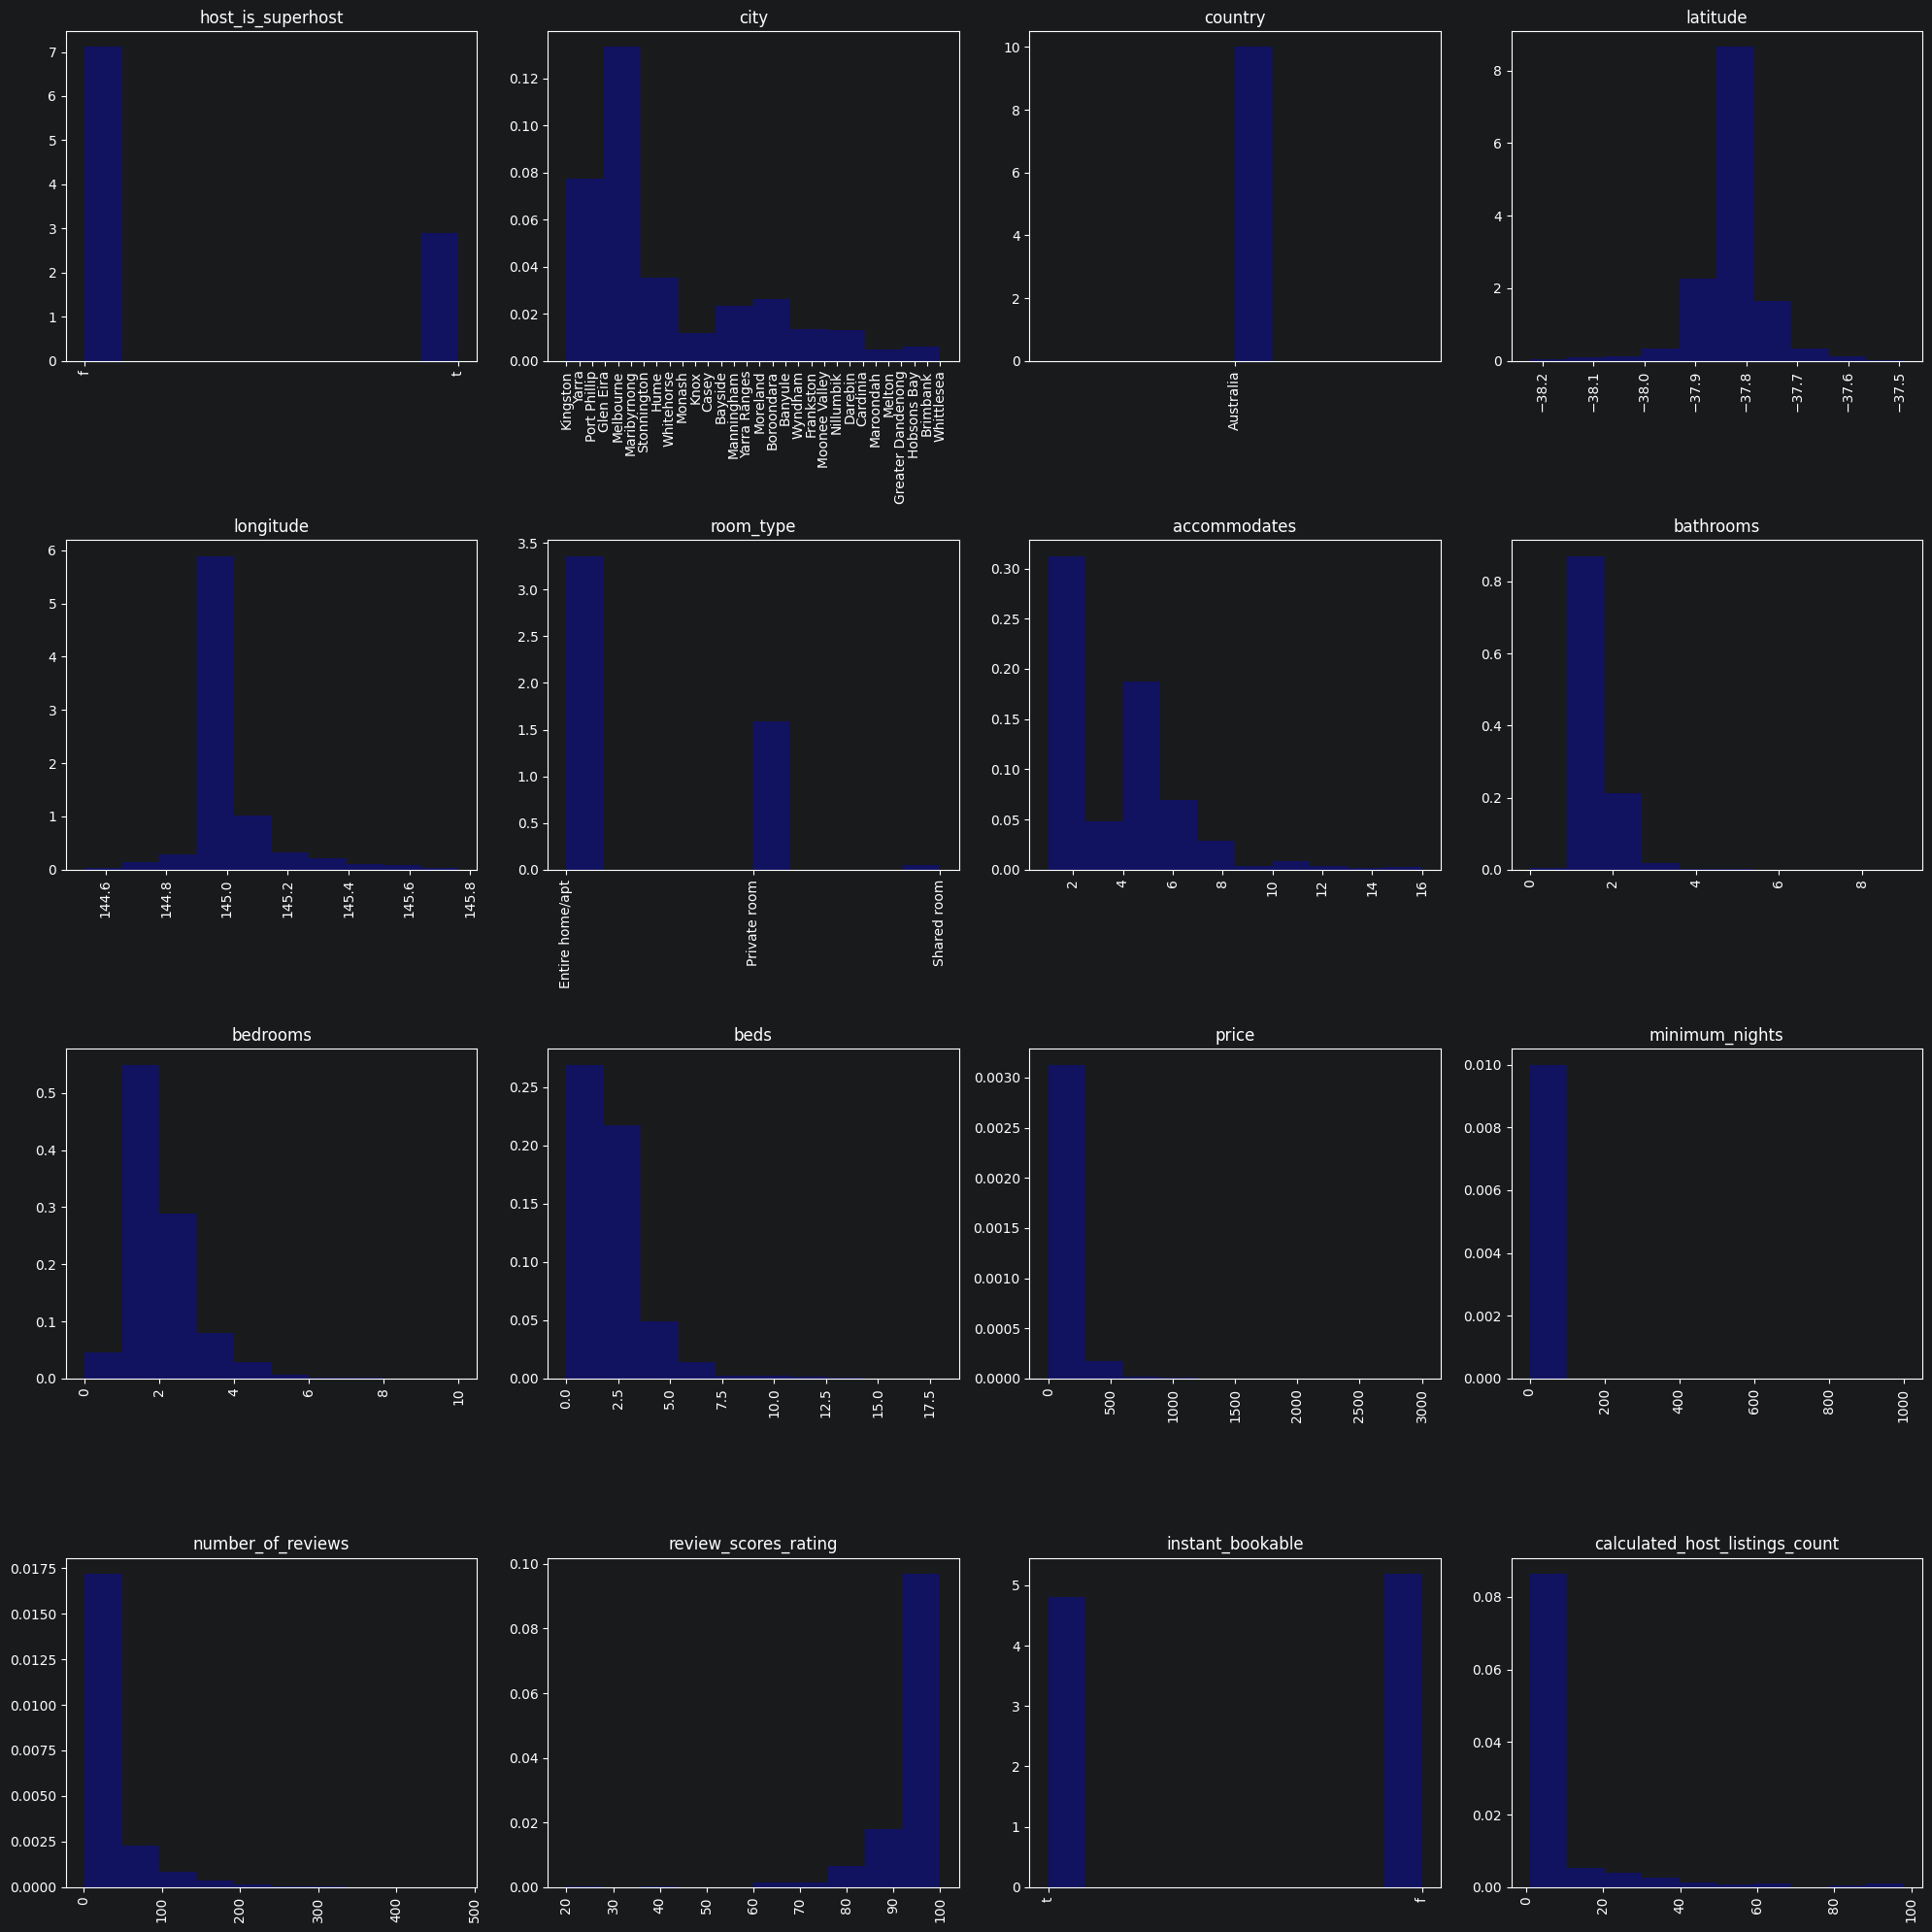

In [4]:
# Histograms to observe basic data distribution

plt.figure(figsize=(20,20))
for i, col in enumerate(train_frame.columns):
    plt.subplot(4,4,i+1)
    plt.hist(train_frame[col], alpha=0.3, color='b', density=True)
    plt.title(col)
    plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

**Observations**:
- Potential outliers in price, minimum nights, number of reviews, host listing counts, bathrooms, bedrooms, and beds.

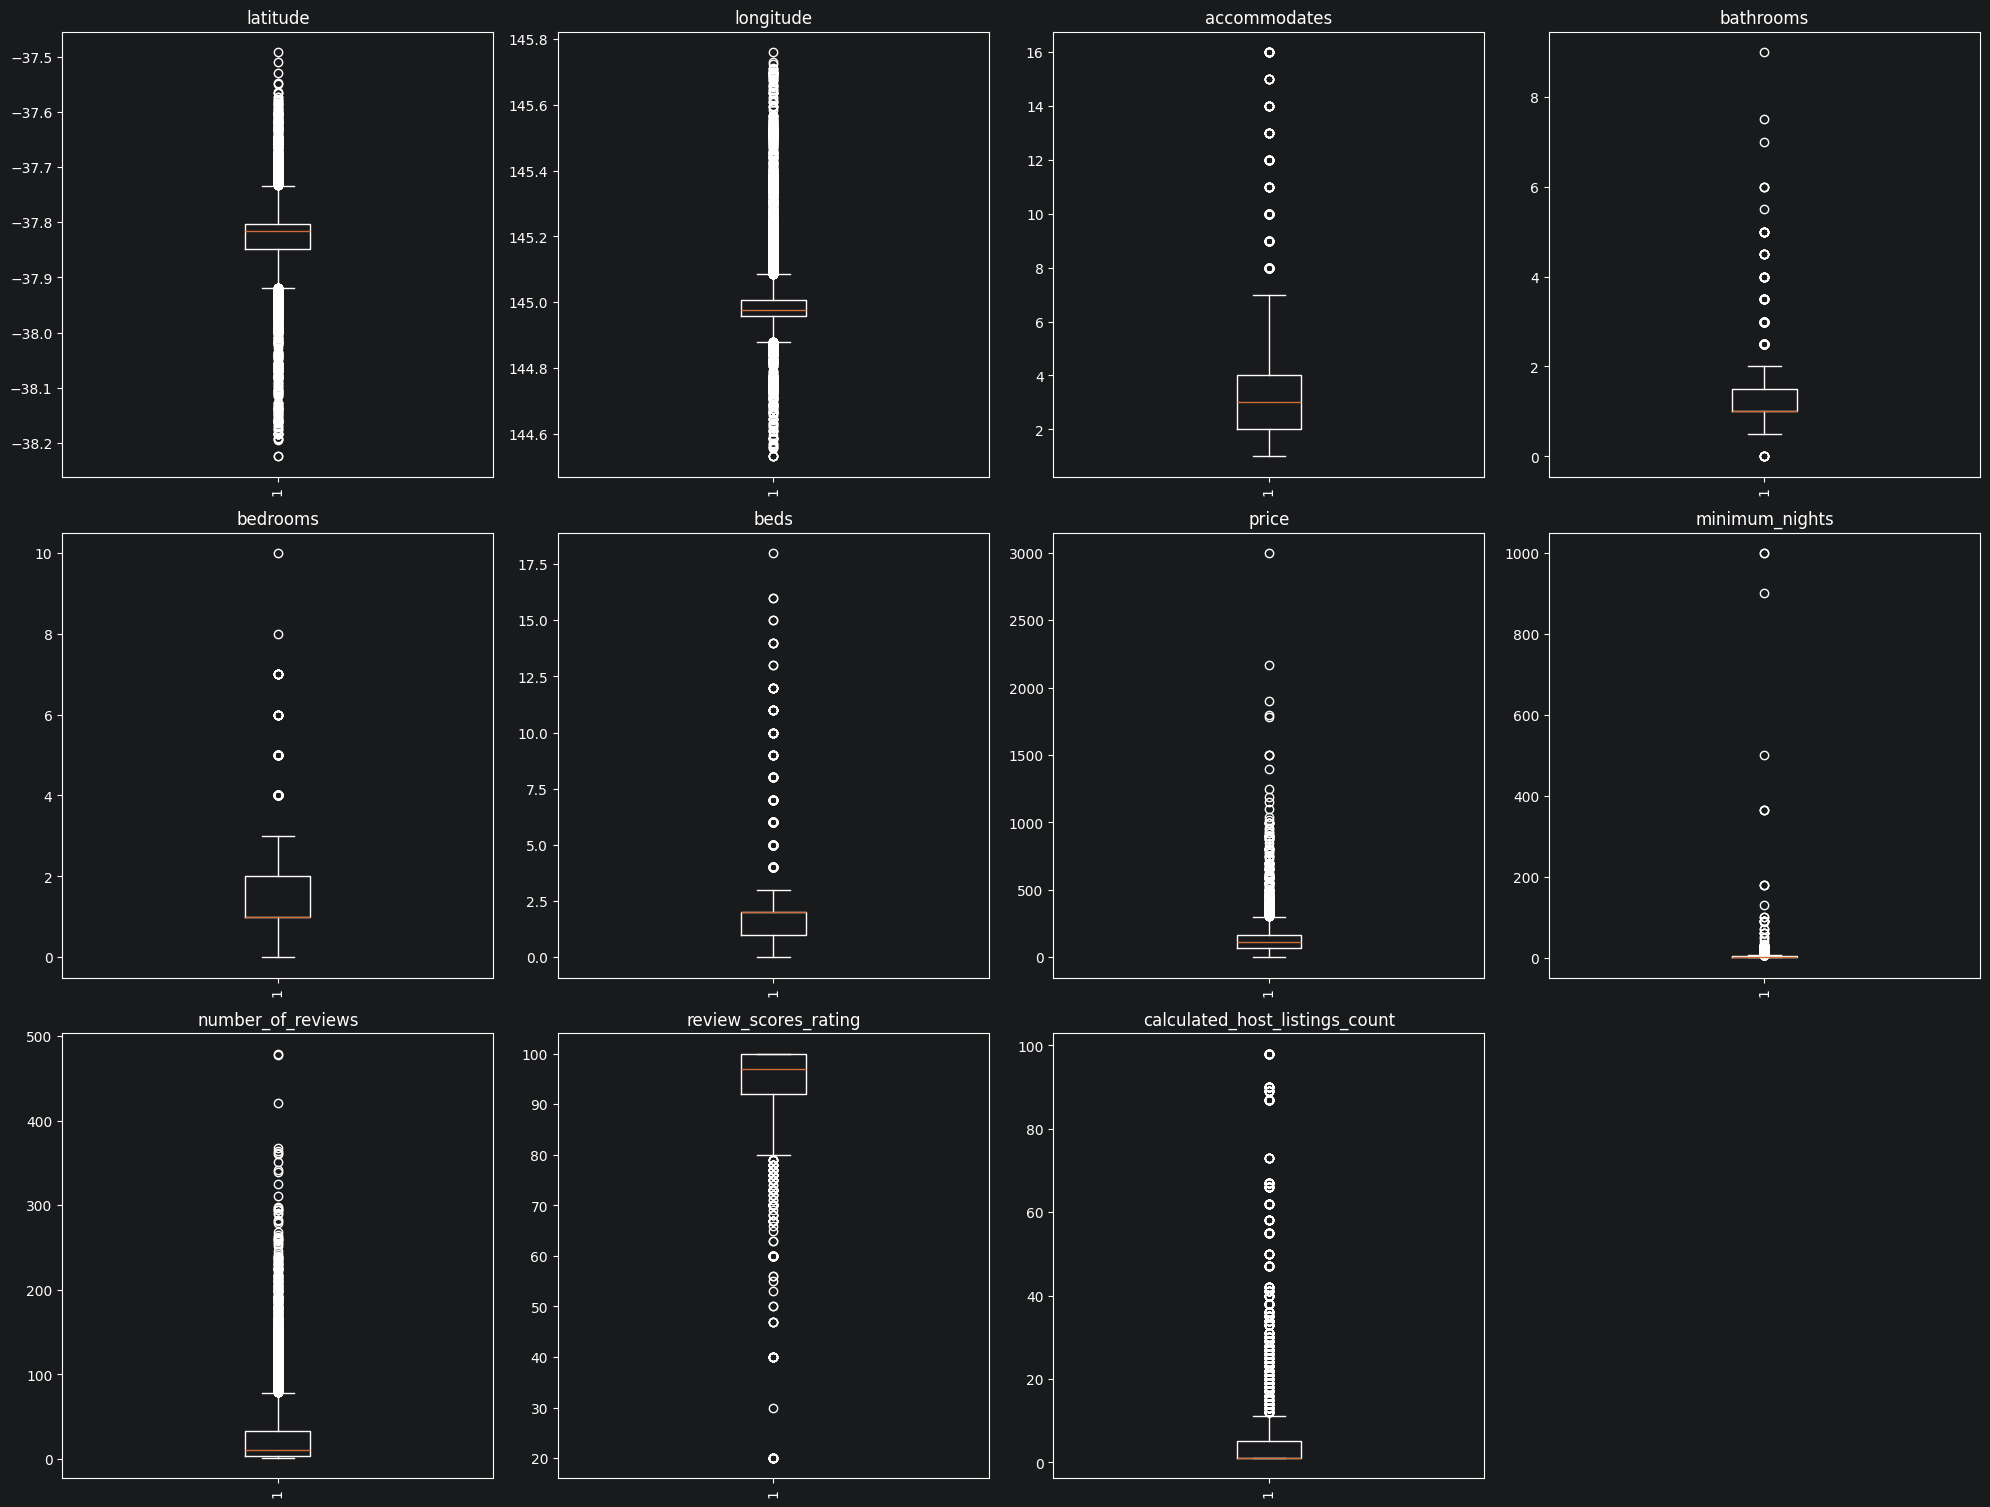

In [5]:
# Box plots to look for features with significant outliers

plt.figure(figsize=(20,20))
numeric_cols = train_frame.select_dtypes(include='number').columns
for i, col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    plt.boxplot(train_frame[col])
    plt.title(col)
    plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

**Observations**
- Major outliers in price and minimum nights. May be worth trimming

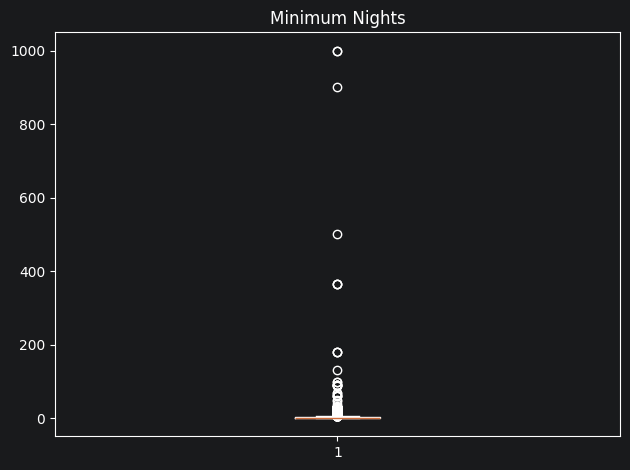

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
16,f,Knox,Australia,-37.842424,145.229196,Private room,2,1.0,1.0,1.0,40,1000,1,20.0,f,1
2269,f,Stonnington,Australia,-37.837648,144.997361,Entire home/apt,5,2.0,2.0,3.0,179,1000,5,95.0,f,1
2100,f,Stonnington,Australia,-37.836130,144.995457,Entire home/apt,5,2.0,2.0,3.0,199,900,57,93.0,t,30
211,f,Melbourne,Australia,-37.830081,144.986887,Entire home/apt,2,1.0,2.0,1.0,138,500,1,80.0,f,1
1972,f,Glen Eira,Australia,-37.886207,145.066779,Private room,2,1.0,1.0,1.0,55,365,6,97.0,f,1
8262,f,Darebin,Australia,-37.772106,144.998408,Entire home/apt,4,1.0,2.0,1.0,800,365,5,100.0,t,1
8458,f,Melbourne,Australia,-37.800621,144.955718,Entire home/apt,3,1.0,2.0,2.0,165,365,2,80.0,f,1
3219,f,Maroondah,Australia,-37.815598,145.236882,Private room,1,2.0,1.0,1.0,28,180,1,100.0,f,1
3570,f,Yarra,Australia,-37.781276,144.987836,Private room,1,1.0,1.0,1.0,37,180,1,100.0,f,1
7714,f,Monash,Australia,-37.918750,145.141977,Private room,1,1.5,1.0,1.0,40,180,2,100.0,f,1


In [6]:
plt.boxplot(train_frame['minimum_nights'])
plt.title('Minimum Nights')
plt.tight_layout()
plt.show()

# Check for top 20 highest minimum nights
train_frame.nlargest(20, 'minimum_nights')

**Obervations - Boxplot**
- 1000 nights is most likely an error. Not representative of the average Airbnb listing.
- The two values below 1000 could be seen the same way.
- There is a circle just below 400. I would guess it would be ~1 year, which could be seen as a sort of long-term stay rental agreement through Airbnb. Though it may be technically correct, it could also be a candidate for removal, as it is very much not the norm and would skew data. Other high value stays could be seen similarly.

**Observations - Largest values**
- As expected, 365 days comes up quite a lot. Supposedly for a long term rental agreement.
- Anything above is likely too much of an outlier to consider keeping.
- Another option is to cap anything above ~31 days as a general long-term stay.

In [7]:
# Number of values above specific values (1 year, 1 month, 1 week)
num_train = train_frame.shape[0]
num_train_year = (train_frame['minimum_nights'] > 365).sum()
num_train_month = (train_frame['minimum_nights'] > 31).sum()
num_train_week = (train_frame['minimum_nights'] > 7).sum()

num_test = unknown_frame.shape[0]
num_test_year = (unknown_frame['minimum_nights'] > 365).sum()
num_test_month = (unknown_frame['minimum_nights'] > 31).sum()
num_test_week = (unknown_frame['minimum_nights'] > 7).sum()

print("Percentage of long stays:")
print(f"Training entries with minimum stay over 1 year: {num_train_year} / {num_train} : {round((num_train_year / num_train) * 100, 2)}%")
print(f"Training entries with minimum stay over 1 month: {num_train_month} / {num_train} : {round((num_train_month / num_train) * 100, 2)}%")
print(f"Training entries with minimum stay over 1 weeks: {num_train_week} / {num_train} : {round((num_train_week / num_train) * 100, 2)}%")
print()
print(f"Test entries with minimum stay over 1 year: {num_test_year} / {num_test} : {round((num_test_year / num_test) * 100, 2)}%")
print(f"Test entries with minimum stay over 1 month: {num_test_month} / {num_test} : {round((num_test_month / num_test) * 100, 2)}%")
print(f"Test entries with minimum stay over 1 weeks: {num_test_week} / {num_test} : {round((num_test_week / num_test) * 100, 2)}%")
print()
print("Raw data:")
print(train_frame['minimum_nights'].describe())
print()
print("Minimum nights <= 7:")
print(train_frame[train_frame['minimum_nights'] <= 7]['minimum_nights'].describe())

Percentage of long stays:
Training entries with minimum stay over 1 year: 4 / 8586 : 0.05%
Training entries with minimum stay over 1 month: 29 / 8586 : 0.34%
Training entries with minimum stay over 1 weeks: 212 / 8586 : 2.47%

Test entries with minimum stay over 1 year: 4 / 8585 : 0.05%
Test entries with minimum stay over 1 month: 33 / 8585 : 0.38%
Test entries with minimum stay over 1 weeks: 207 / 8585 : 2.41%

Raw data:
count    8586.000000
mean        3.158747
std        20.788007
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max      1000.000000
Name: minimum_nights, dtype: float64

Minimum nights <= 7:
count    8374.000000
mean        2.071531
std         1.371780
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         7.000000
Name: minimum_nights, dtype: float64


**Observations**
- In the raw data, the mean is 3.16, but the median is 2.0, suggesting a small number of outliers are disproportionately affecting the distribution
- Only ~2.5% of listings are even over a week. Removing these could give a more accurate model for the intended use of Airbnb
- Capping the minimum nights to 7 keeps the median at 2.0, but mean goes from 3.16 to 2.07
- Standard deviation also becomes much smaller (1.37 instead of 20.78)
- These changes are in line with our predictions regarding outliers.
- Price is another feature wish a significant mean/median discrepancy.

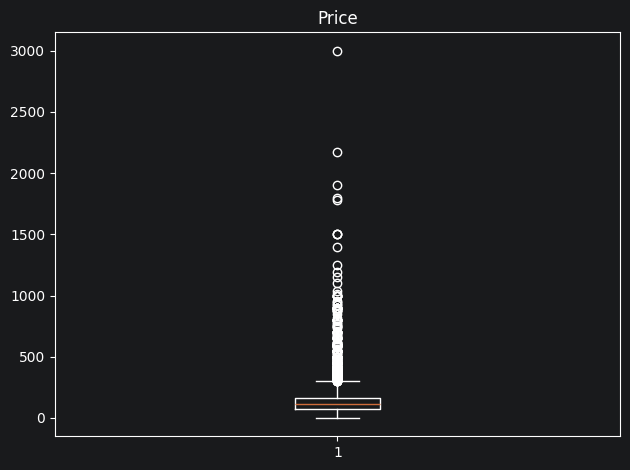

Training entries with nightly cost of >= $1500: 8 / 8586 : 0.09%

count    8586.000000
mean      139.771372
std       123.293376
min         0.000000
25%        71.000000
50%       115.000000
75%       162.750000
max      3000.000000
Name: price, dtype: float64

count    8578.000000
mean      138.134763
std       110.147099
min         0.000000
25%        71.000000
50%       115.000000
75%       161.750000
max      1400.000000
Name: price, dtype: float64


In [8]:
# Price boxplot
plt.boxplot(train_frame['price'])
plt.title('Price')
plt.tight_layout()
plt.show()

# Number of entries over $999 per night
num_train = train_frame.shape[0]
num_train_luxury = (train_frame['price'] >= 1500).sum()

print(f"Training entries with nightly cost of >= $1500: {num_train_luxury} / {num_train} : {round((num_train_luxury / num_train) * 100, 2)}%")
print()
print(train_frame['price'].describe())
print()
print(train_frame[train_frame['price'] < 1500]['price'].describe())

**Observations**
- Majority of listings cap out at ~$1500
- Since there are so few ~\$1500 rooms (0.01%), the model will have issues learning patterns from these extreme values
- Little incentive to keep them in the training data. Could be another feature to cull

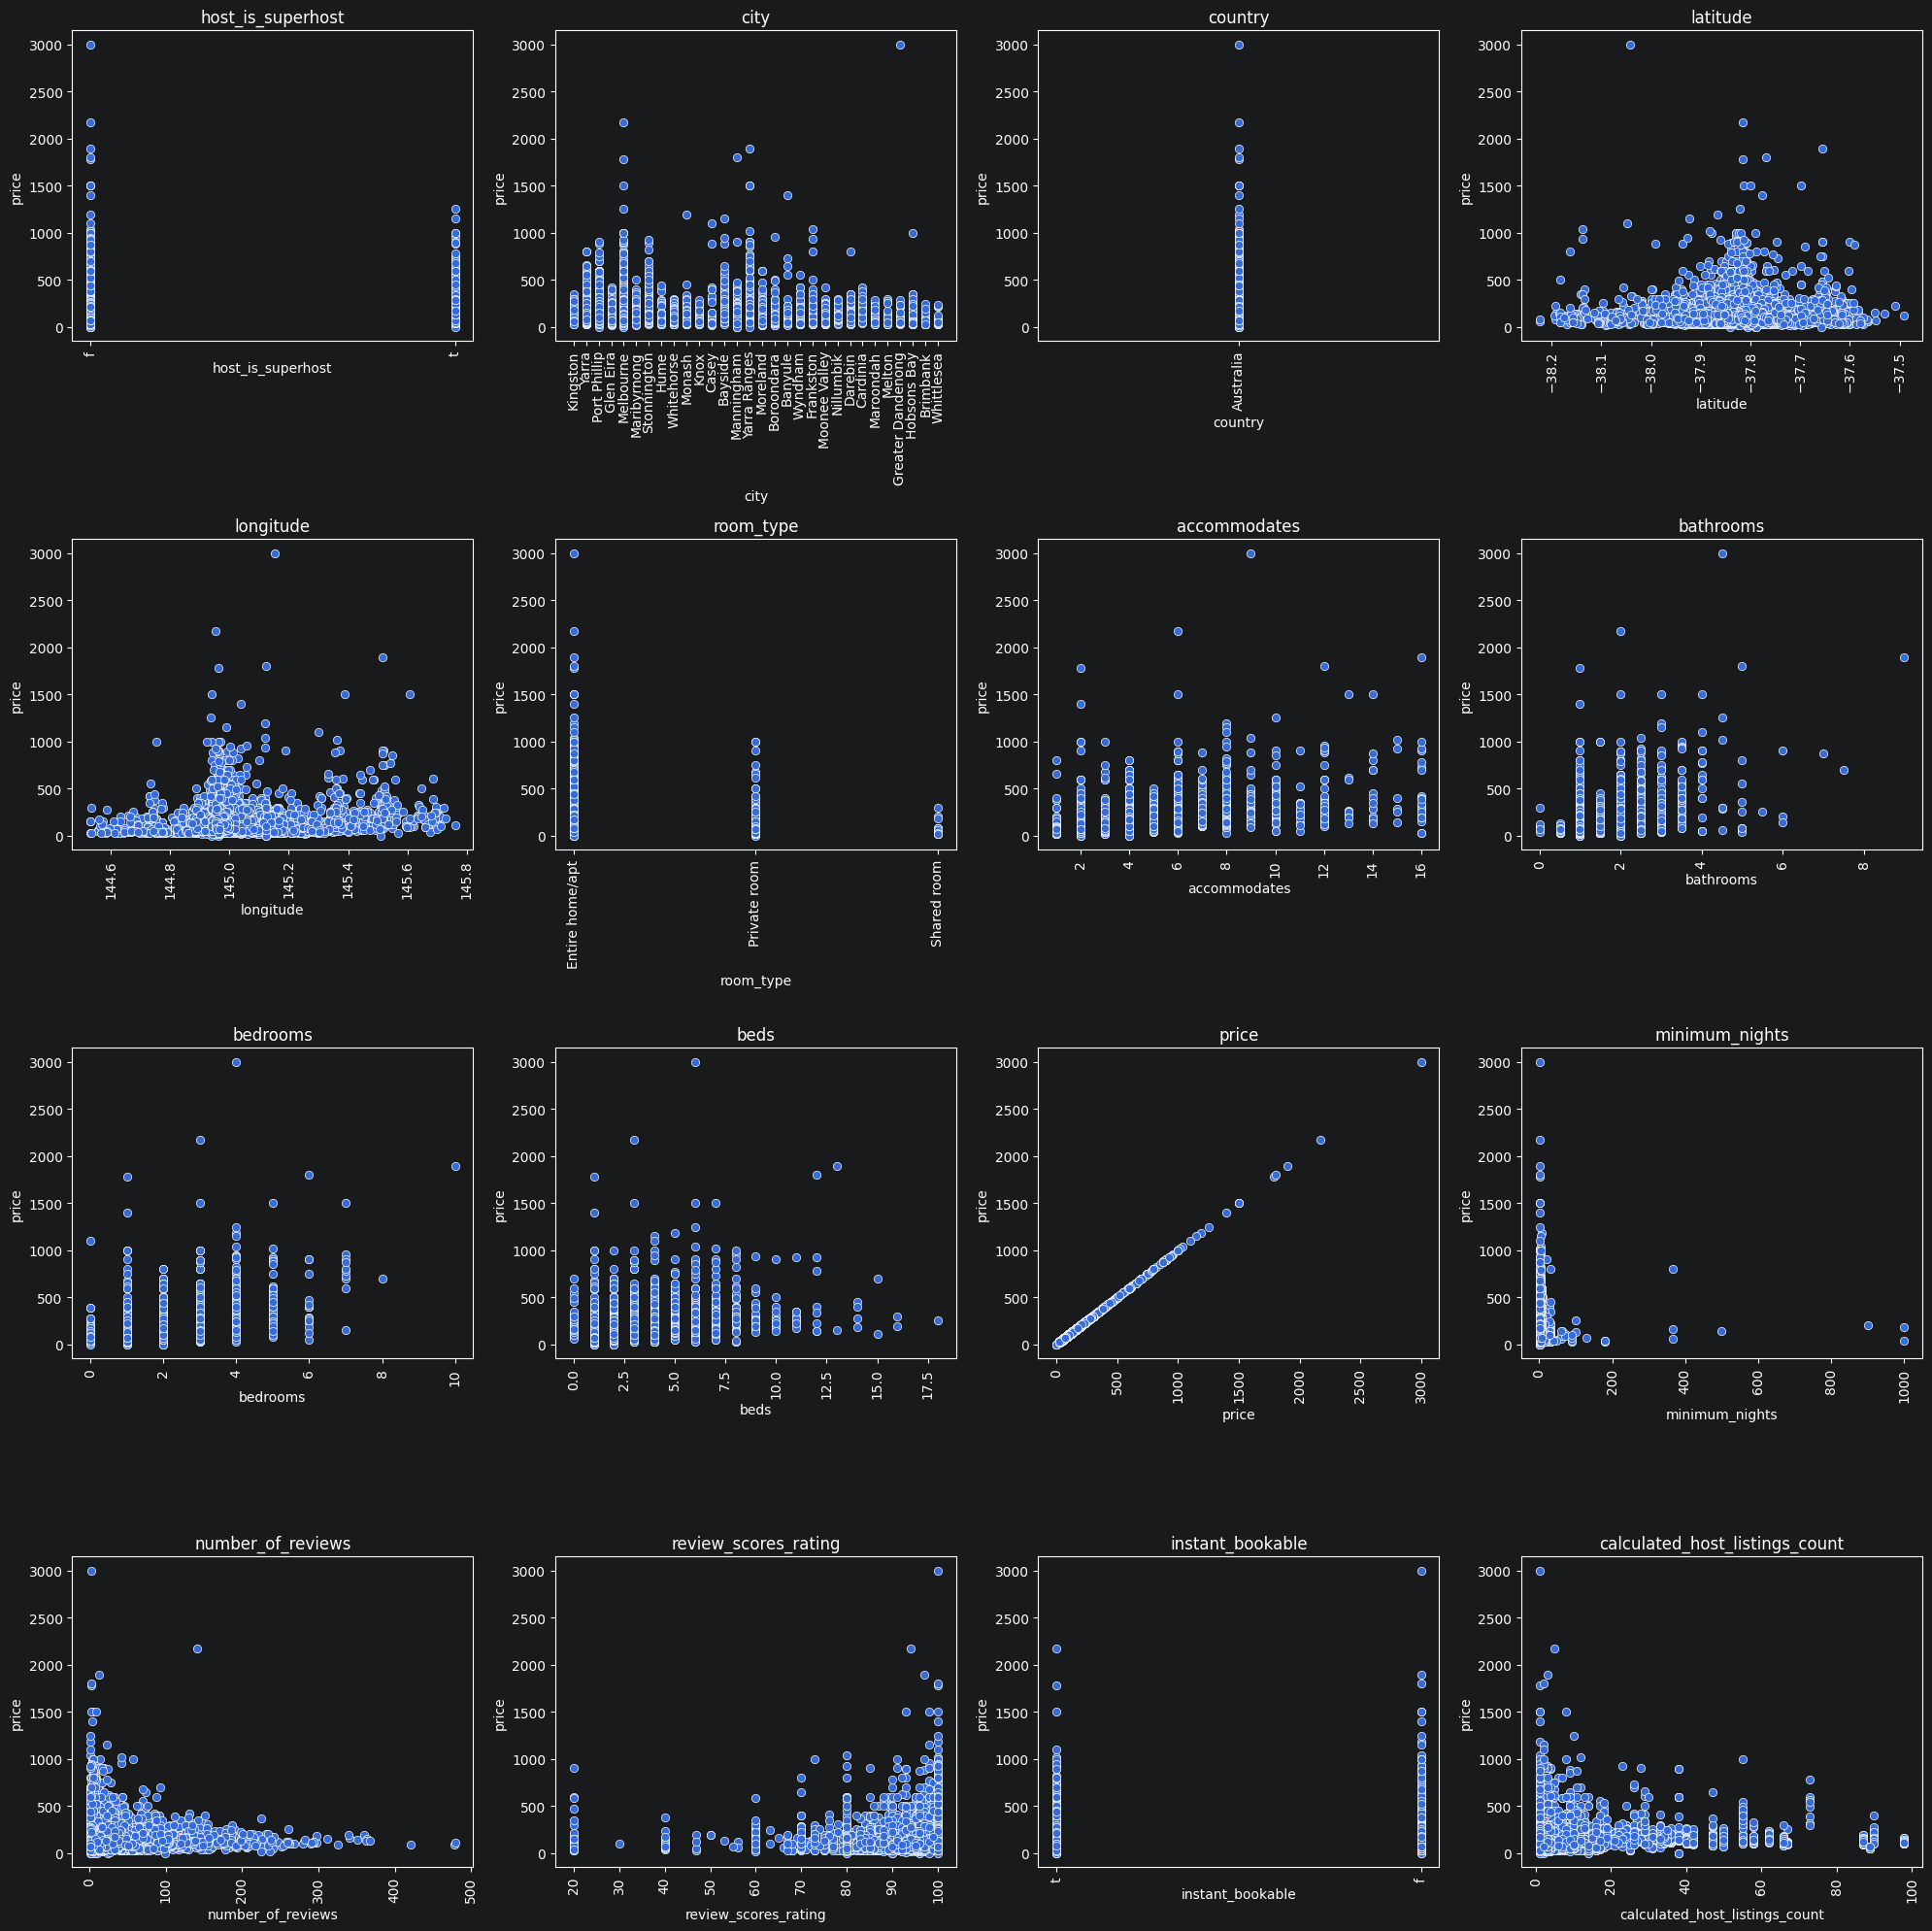

In [9]:
# Scatter plot to examine distribution of features against the target (price)

plt.figure(figsize=(20, 20))
for i, col in enumerate(train_frame.columns):
    plt.subplot(4, 4, i+1)
    sns.scatterplot(data=train_frame, x=col, y='price')
    plt.title(col)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observations**
- The few extremely high price outliers widen the scope of these graphs significantly
- Country gives no information, as every listing is in Australia
- superhost & instantly bookable status are difficult to interpret with a scatterplot, but these binary values seem to have little bearing on price
- *City*: Melbourne, Port Phillip, Stonnington, and the Yarra Ranges seem to have the highest cost top-end, non-outlier properties
- *Latitude & Longitude*: High variance areas (~37.8 Lat, ~145.0 Long) indicate denser locations
- *Room type*: Entire home/apt > Private Room > Shared Room in general. There is still some variance though
- *Accommodates*: sharp decline at >2. Higher accommodation increases the baseline, signalling higher average cost
- *Bathrooms*: <1 is a negative. More bathrooms increases the baseline, signalling higher average cost
- *Bedrooms*: <1 is a negative. Slight bell-curve, peaking at 4. More bedrooms increases the baseline, signalling higher average cost.
- *Beds*: <1 is a negative. Above ~8, top-end prices seem to trend down. Perhaps higher capacity stays are lower-quality overall. Higher bed count still increases baseline, signalling higher average cost
- *Minimum nights*: VAST majority are very short stays. Long-duration stays seem to be generally very cheap, except for one instance at around the 365-day minimum stay range, with a ~$800/night cost
- *Number of reviews*: More reviews = less cost. It seems that the cheaper stays are more reviewed.
- *Review Score*: Higher average reviews generally relates to more cost
- *Host listings count*: Hosts with fewer listings trend higher. Makes sense if property management companies offer lower prices, considering they would care less about the individual stay prices. More throughput means more money for less effort than creating a small number of very high quality stays



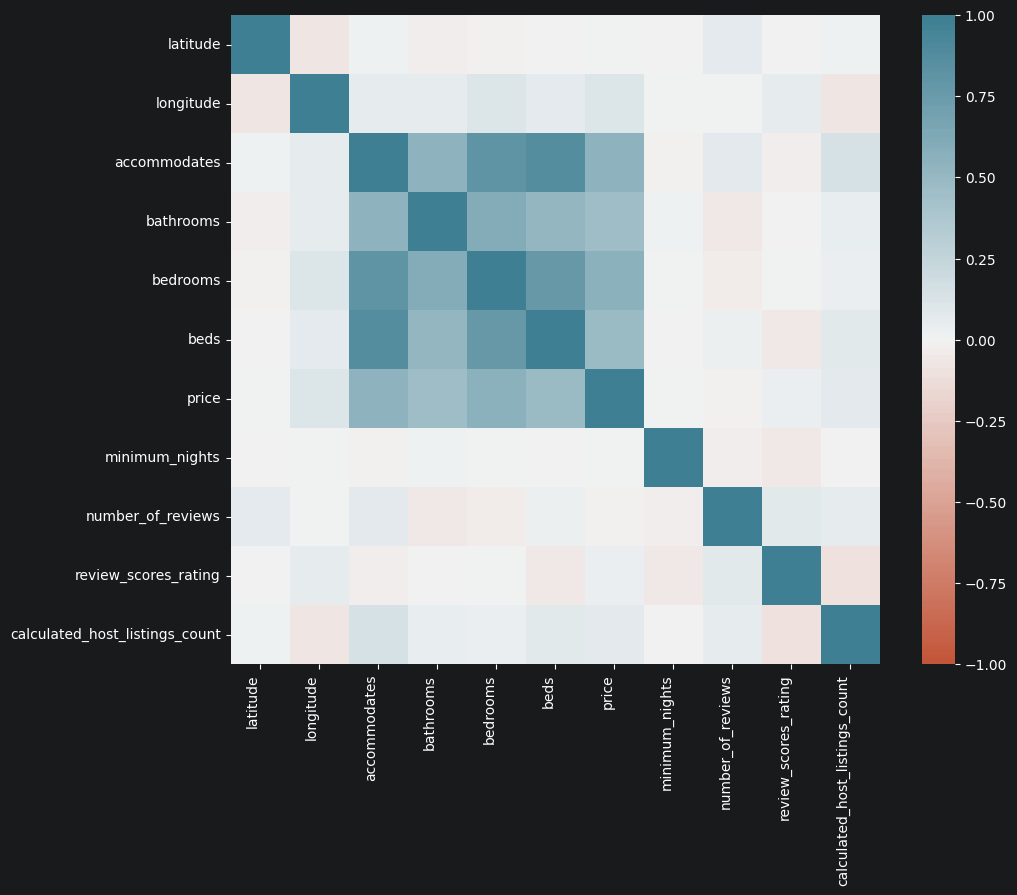

In [10]:
# Heatmap to further examine correlation

num_cols = train_frame.select_dtypes(include=['int64', 'float64']).columns

f, ax = plt.subplots(figsize=(11, 9))
corr = train_frame[num_cols].corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
)
plt.tight_layout()
plt.show()

**Observations**
- Only a few features seem to meaningfully affect price: number of people the listing can accommodate, number of bathrooms, number of bedrooms, and number of beds
- Rough correlation magnitude: accommodates = bedrooms > beds = bathrooms >> everything else

# 3: Data Pre-Processing and Transformation

In [11]:
# Dataset Splitting
# Training dataset must be split to get a workable test set (with a price column) to facilitate supervised training
# After splitting, most changes must be applied to all 3 data sets: train, test, unknown

# Remove the country column, as it provides no meaningful data
train_frame = train_frame.drop(columns=['country'])
unknown_frame = unknown_frame.drop(columns=['country'])

with pd.option_context('mode.chained_assignment', None):
    train_split, test_split = train_test_split(train_frame, test_size=0.2, shuffle=True, random_state=42)

# Remove outliers from training data only
train_split = train_split[(train_split['price'] > 0) & (train_split['minimum_nights'] <= 31)] # Remove error and minimum nights outliers

# Separate price from the data
train_x = train_split.drop(columns=['price'])
train_y = train_split['price']

test_x = test_split.drop(columns=['price'])
test_y = test_split['price']

unk_x = unknown_frame.copy() # No need to split. the test_data csv file has no price column

# Change superhost and intant booking columns to be binary
train_x[['host_is_superhost', 'instant_bookable']] = (train_x[['host_is_superhost', 'instant_bookable']] == 't').astype(int)
test_x[['host_is_superhost', 'instant_bookable']] = (test_x[['host_is_superhost', 'instant_bookable']] == 't').astype(int)
unk_x[['host_is_superhost', 'instant_bookable']] = (unk_x[['host_is_superhost', 'instant_bookable']] == 't').astype(int)

# train_x.head(10)

**Notes**
- train_split is modified to change to cull outliers if needed
- city and room_type still have str type values which need to be changed to int/float

In [12]:
# perform one hot encoding on city and room type columns
encoder = OneHotEncoder(handle_unknown='ignore')

# Fit once on training data, transform on all datasets
encoder.fit(train_x[['city', 'room_type']])
train_enc = encoder.transform(train_x[['city', 'room_type']]).toarray()
test_enc = encoder.transform(test_x[['city', 'room_type']]).toarray()
unk_enc = encoder.transform(unk_x[['city', 'room_type']]).toarray()

# Add these new binary values to the data frames, and drop the originals
encoded_cols = encoder.get_feature_names_out(['city', 'room_type'])
train_x = pd.concat([train_x.drop(columns=['city', 'room_type']), pd.DataFrame(train_enc, columns=encoded_cols, index=train_x.index)], axis=1)
test_x = pd.concat([test_x.drop(columns=['city', 'room_type']), pd.DataFrame(test_enc, columns=encoded_cols, index=test_x.index)], axis=1)
unk_x = pd.concat([unk_x.drop(columns=['city', 'room_type']), pd.DataFrame(unk_enc, columns=encoded_cols, index=unk_x.index)], axis=1)

# train_x.head(10)

In [13]:
# Normalise skewing and perform scaling

# To observe the different effects of pre-processing techniques, we have x different sets, with different techniques applied:
# Raw data:             train_x, test_x, unk_x

# Only scaling:         train_x_scaled, test_x_scaled, unk_x_scaled
train_x_scaled = train_x.copy().astype('float')
test_x_scaled = test_x.copy().astype('float')
unk_scaled = unk_x.copy().astype('float')

# Transformed & scaled: train_x_scaled_tf, train_x_scaled_tf, unk_x_scaled_tf
train_x_scaled_tf = train_x.copy().astype('float')
test_x_scaled_tf = test_x.copy().astype('float')
unk_scaled_tf = unk_x.copy().astype('float')

# SCALE -------------------------------------------------------------------------------------------------------------
scaler = StandardScaler().fit(train_x_scaled)
train_x_scaled = scaler.transform(train_x_scaled)
test_x_scaled = scaler.transform(test_x_scaled)
unk_scaled = scaler.transform(unk_scaled)

# TRANSFORM AND SCALE ---------------------------------------------------------------------------------------------------------
# Power transformation to skewed columns, standardisation for the others

skewed_columns = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count']
other_columns = list(set(train_x_scaled_tf.columns).difference(set(skewed_columns)))

power_transformer = PowerTransformer(method='yeo-johnson', standardize=True).fit(train_x_scaled_tf.loc[:, skewed_columns])
train_x_scaled_tf.loc[:, skewed_columns] = power_transformer.transform(train_x_scaled_tf.loc[:, skewed_columns])
test_x_scaled_tf.loc[:, skewed_columns] = power_transformer.transform(test_x_scaled_tf.loc[:, skewed_columns])
unk_scaled_tf.loc[:, skewed_columns] = power_transformer.transform(unk_scaled_tf.loc[:, skewed_columns])

standard_scaler = StandardScaler().fit(train_x_scaled_tf.loc[:,other_columns])
train_x_scaled_tf.loc[:, other_columns] = standard_scaler.transform(train_x_scaled_tf.loc[:, other_columns])
test_x_scaled_tf.loc[:, other_columns] = standard_scaler.transform(test_x_scaled_tf.loc[:, other_columns])
unk_scaled_tf.loc[:, other_columns] = standard_scaler.transform(unk_scaled_tf.loc[:, other_columns])

# Log-scale the training data prices to account for right-skewedness
train_y_log = np.log1p(train_y)
# log-scaled prices must be reverted to prices after predictions

# pd.DataFrame(train_x_scaled, columns=train_x.columns, index=train_x.index).head(100)

**Notes**
- Standard scaling is "more robust towards outliers", according to course material, so we use standard scaling instead of minmax
- Price is still very right skewed. Log-scaling can reduce right-skewedness, but log-scaled prices must be reverted after predictions

# 4: Model Construction

## 4.1: Basic Linear Regression

In [14]:
# Train using the log target values to reduce the skew from outliers
lr_raw_l = LinearRegression().fit(train_x, train_y_log)
lr_raw_d = LinearRegression().fit(train_x, train_y)
lr_scaled_l = LinearRegression().fit(train_x_scaled, train_y_log)
lr_scaled_d = LinearRegression().fit(train_x_scaled, train_y)
lr_scaled_tf_l = LinearRegression().fit(train_x_scaled_tf, train_y_log)
lr_scaled_tf_d = LinearRegression().fit(train_x_scaled_tf, train_y)

# Predict log target values
lr_pred_raw_l = lr_raw_l.predict(test_x)
lr_pred_raw_d = lr_raw_d.predict(test_x)
lr_pred_scaled_l = lr_scaled_l.predict(test_x_scaled)
lr_pred_scaled_d = lr_scaled_d.predict(test_x_scaled)
lr_pred_scaled_tf_l = lr_scaled_tf_l.predict(test_x_scaled_tf)
lr_pred_scaled_tf_d = lr_scaled_tf_d.predict(test_x_scaled_tf)

# invert log to get dollar results
lr_pred_raw = np.expm1(lr_pred_raw_l)
lr_pred_scaled = np.expm1(lr_pred_scaled_l)
lr_pred_scaled_tf = np.expm1(lr_pred_scaled_tf_l)

**Notes**
- For each dataset (raw, scaled, scaled and transformed), we train two models. One using log-scaled targets, which are converted afterwards, and one using the raw target values.

In [15]:
# R2 for: log-converted, raw, log-scaled target
# For each, Root mean square error, Mean absolute Error

test_y_log = np.log1p(test_y) # Log-scaled target

print("1: price predicted on a log scale, then transformed back\n2: price predicted using raw dollar values\n3: log-scale prediction vs log-scale target\n")

# RAW -----------------------------------------------
r2_raw = r2_score(test_y, lr_pred_raw)
rmse_raw = root_mean_squared_error(test_y, lr_pred_raw)
mae_raw = mean_absolute_error(test_y, lr_pred_raw)

r2_raw_r = r2_score(test_y, lr_pred_raw_d)
rmse_raw_r = root_mean_squared_error(test_y, lr_pred_raw_d)
mae_raw_r = mean_absolute_error(test_y, lr_pred_raw_d)

r2_raw_log = r2_score(test_y_log, lr_pred_raw_l)
print("Model trained on raw x values:")
print(f"1: R2 = {r2_raw:.3f}, RMSE = {rmse_raw:.3f}, MAE = {mae_raw:.3f}")
print(f"2: R2 = {r2_raw_r:.3f}, RMSE = {rmse_raw_r:.3f}, MAE = {mae_raw_r:.3f}")
print(f"3: R2 = {r2_raw_log:.3f}")
print()

# SCALED -----------------------------------------------
r2_scaled = r2_score(test_y, lr_pred_scaled)
rmse_scaled = root_mean_squared_error(test_y, lr_pred_scaled)
mae_scaled = mean_absolute_error(test_y, lr_pred_scaled)

r2_scaled_r = r2_score(test_y, lr_pred_scaled_d)
rmse_scaled_r = root_mean_squared_error(test_y, lr_pred_scaled_d)
mae_scaled_r = mean_absolute_error(test_y, lr_pred_scaled_d)

r2_scaled_log = r2_score(test_y_log, lr_pred_scaled_l)
print("Model trained on scaled x values:")
print(f"1: R2 = {r2_scaled:.3f}, RMSE = {rmse_scaled:.3f}, MAE = {mae_scaled:.3f}")
print(f"2: R2 = {r2_scaled_r:.3f}, RMSE = {rmse_scaled_r:.3f}, MAE = {mae_scaled_r:.3f}")
print(f"3: R2 = {r2_scaled_log:.3f}")
print()

# SCALED, Transformed -----------------------------------------------
r2_scaled_tf = r2_score(test_y, lr_pred_scaled_tf)
rmse_scaled_tf = root_mean_squared_error(test_y, lr_pred_scaled_tf)
mae_scaled_tf = mean_absolute_error(test_y, lr_pred_scaled_tf)

r2_scaled_tf_r = r2_score(test_y, lr_pred_scaled_tf_d)
rmse_scaled_tf_r = root_mean_squared_error(test_y, lr_pred_scaled_tf_d)
mae_scaled_tf_r = mean_absolute_error(test_y, lr_pred_scaled_tf_d)

r2_scaled_tf_log = r2_score(test_y_log, lr_pred_scaled_tf_l)
print("Model trained on scaled and transformed x values:")
print(f"1: R2 = {r2_scaled_tf:.3f}, RMSE = {rmse_scaled_tf:.3f}, MAE = {mae_scaled_tf:.3f}")
print(f"2: R2 = {r2_scaled_tf_r:.3f}, RMSE = {rmse_scaled_tf_r:.3f}, MAE = {mae_scaled_tf_r:.3f}")
print(f"3: R2 = {r2_scaled_tf_log:.3f}")

1: price predicted on a log scale, then transformed back
2: price predicted using raw dollar values
3: log-scale prediction vs log-scale target

Model trained on raw x values:
1: R2 = 0.430, RMSE = 100.653, MAE = 40.999
2: R2 = 0.394, RMSE = 103.804, MAE = 48.017
3: R2 = 0.631

Model trained on scaled x values:
1: R2 = 0.430, RMSE = 100.653, MAE = 40.999
2: R2 = 0.394, RMSE = 103.804, MAE = 48.017
3: R2 = 0.631

Model trained on scaled and transformed x values:
1: R2 = 0.369, RMSE = 105.939, MAE = 43.149
2: R2 = 0.345, RMSE = 107.937, MAE = 50.738
3: R2 = 0.634


**Notes**
- Raw vs StandardScaler give identical results. Scaling has no effect on predictions, but the scaled variant must still be used for Ridge/Lasso, to ensure the penalties are fair across features
- Log-scaled target always performs better. Log transformation reduces the influence of the extreme price outliers
- PowerTransformer performs worse than just scaling. Though features were skewed, reshaping made the relationship with the target less linear

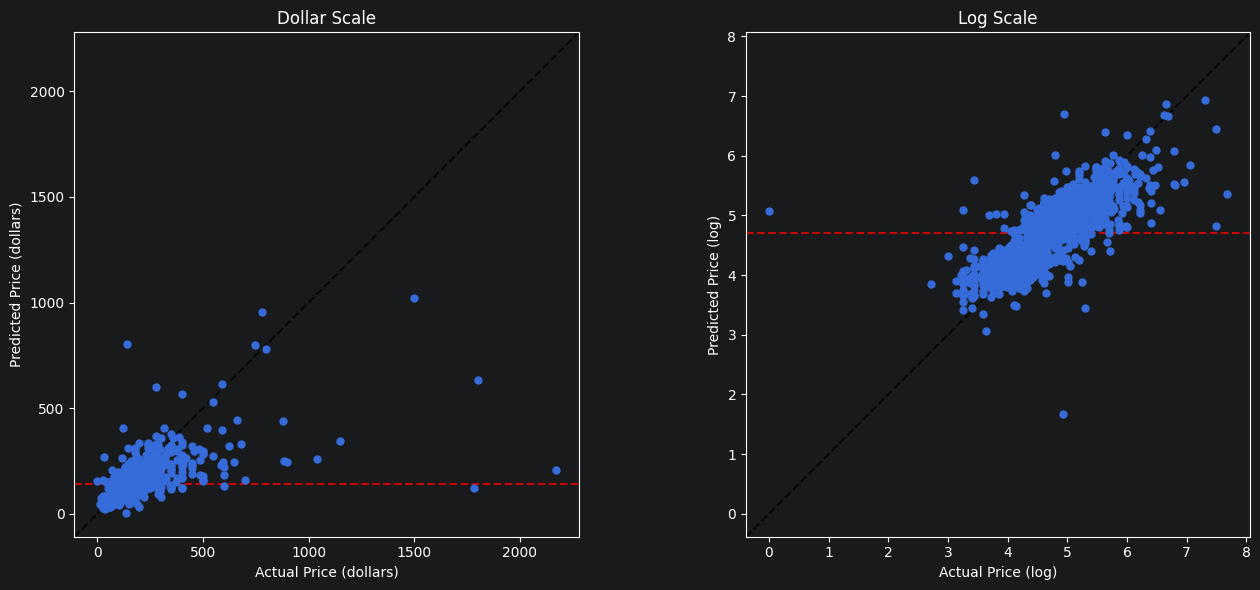

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Dollar Scale
ax1.scatter(test_y, lr_pred_scaled, s=25, zorder=10)
lims = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),  # min of both axes
    np.max([ax1.get_xlim(), ax1.get_ylim()]),  # max of both axes
]
ax1.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax1.plot(lims, [np.mean(test_y),]*2, 'r--', alpha=0.75, zorder=0)
ax1.set_aspect('equal')
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_xlabel('Actual Price (dollars)')
ax1.set_ylabel('Predicted Price (dollars)')
ax1.set_title('Dollar Scale')

# Log Scale
ax2.scatter(test_y_log, lr_pred_scaled_l, s=25, zorder=10)
lims = [
    np.min([ax2.get_xlim(), ax2.get_ylim()]),
    np.max([ax2.get_xlim(), ax2.get_ylim()])
]
ax2.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax2.plot(lims, [np.mean(test_y_log),]*2, 'r--', alpha=0.75, zorder=0)
ax2.set_aspect('equal')
ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_xlabel('Actual Price (log)')
ax2.set_ylabel('Predicted Price (log)')
ax2.set_title('Log Scale')

plt.tight_layout()
plt.show()

**Notes**
- Basic Linear Regression predicts prices rather poorly, but follows the general shape of the data, trending a little too high
- When the target is log-scaled (reduced effect of outliers), LR model accuracy is significantly better. The severity of the outliers has a great effect on the model

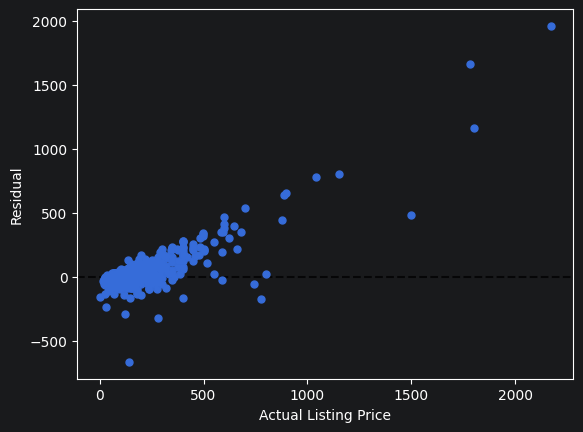

In [17]:
fig, ax = plt.subplots()
ax.scatter(test_y, test_y-lr_pred_scaled, s=25, zorder=10)

xlims = ax.get_xlim()
ax.plot(xlims, [0.0,]*2, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(xlims)

plt.xlabel('Actual Listing Price')
plt.ylabel('Residual')

plt.show()

**Notes**
- Redisual plotting reveals a similar story: Listings are predicted generally quite well, but the model is poor at predicting outliers

## 4.2: Ridge Regression

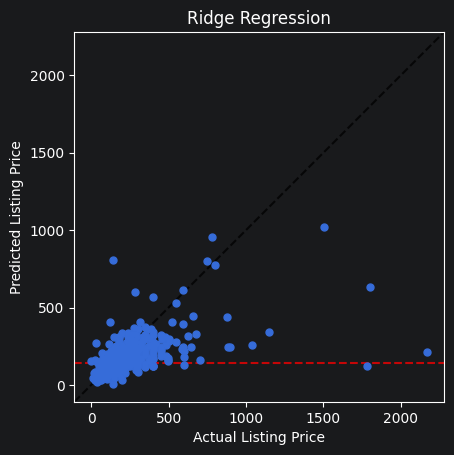

Ridge Regression Predictions:
R2 = 0.430, RMSE = 100.655, MAE = 40.998
log-scaled target: R2 = 0.631


In [18]:
# RIDGE

ridge = Ridge(alpha=1.0).fit(train_x_scaled, train_y_log)
ridge_pred_l = ridge.predict(test_x_scaled)
ridge_pred = np.expm1(ridge_pred_l)

r2_ridge = r2_score(test_y, ridge_pred)
r2_ridge_log = r2_score(test_y_log, ridge_pred_l)
rmse_ridge = root_mean_squared_error(test_y, ridge_pred)
mae_ridge = mean_absolute_error(test_y, ridge_pred)

# Visualisation
fig, ax = plt.subplots()
ax.scatter(test_y, ridge_pred, s=25, zorder=10)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.plot(lims, [np.mean(train_y),]*2, 'r--', alpha=0.75, zorder=0)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Listing Price')
ax.set_ylabel('Predicted Listing Price')
ax.set_title('Ridge Regression')

plt.show()

print("Ridge Regression Predictions:")
print(f"R2 = {r2_ridge:.3f}, RMSE = {rmse_ridge:.3f}, MAE = {mae_ridge:.3f}")
print(f"log-scaled target: R2 = {r2_ridge_log:.3f}")

**Notes**
- Reduces the weight of all coefficients towards 0, acting more heavily on larger coefficients
- Performs almost the same as regular linear regression, signalling that there is no overfitting issues

## 4.3: Lasso Regresion

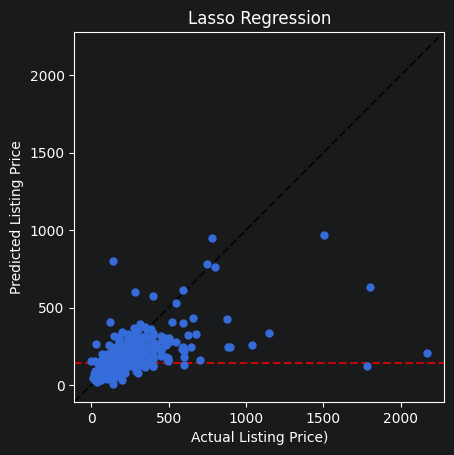

Lasso Regression Predictions:
R2 = 0.428, RMSE = 100.892, MAE = 40.920
log-scaled target: R2 = 0.634


In [19]:
# LASSO

lasso = Lasso(alpha=0.001).fit(train_x_scaled, train_y_log)
lasso_pred_l = lasso.predict(test_x_scaled)
lasso_pred = np.expm1(lasso_pred_l)

r2_lasso = r2_score(test_y, lasso_pred)
r2_lasso_log = r2_score(test_y_log, lasso_pred_l)
rmse_lasso = root_mean_squared_error(test_y, lasso_pred)
mae_lasso = mean_absolute_error(test_y, lasso_pred)

# Visualisation
fig, ax = plt.subplots()
ax.scatter(test_y, lasso_pred, s=25, zorder=10)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.plot(lims, [np.mean(train_y),]*2, 'r--', alpha=0.75, zorder=0)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Listing Price)')
ax.set_ylabel('Predicted Listing Price')
ax.set_title('Lasso Regression')

plt.show()

print("Lasso Regression Predictions:")
print(f"R2 = {r2_lasso:.3f}, RMSE = {rmse_lasso:.3f}, MAE = {mae_lasso:.3f}")
print(f"log-scaled target: R2 = {r2_lasso_log:.3f}")

**Notes**
- Works similarly to Ridge, but can reduce coefficients to 0 if they do close to nothing
- Since most features have some sort of effect, even if small, very few are dropped, and the model works similarly to LR

## 4.4: Model tuning

In [20]:
# Cross Validation to optimise model alphas

ridge_cv = RidgeCV(alphas=np.logspace(-6, 6, 16)).fit(train_x_scaled, train_y_log)
print(f"Optimal Ridge alpha: {ridge_cv.alpha_:.3f}")
print(f"Ridge CV R2: {r2_score(test_y, np.expm1(ridge_cv.predict(test_x_scaled))):.3f}")

lasso_cv = LassoCV(cv=5).fit(train_x_scaled, train_y_log)
print(f"Optimal Lasso alpha: {lasso_cv.alpha_:.3f}")
print(f"Lasso CV R2: {r2_score(test_y, np.expm1(lasso_cv.predict(test_x_scaled))):.3f}")

Optimal Ridge alpha: 100.000
Ridge CV R2: 0.428
Optimal Lasso alpha: 0.001
Lasso CV R2: 0.427


**Notes**
- Cross-validated alphas produce R2 values which are worse than when using the initial alpha
- Likely because the models are trained using log-scaled target values, then converted back to price, so they are optimised for log-scaled values.
- A difference in 0.002 is so small it could be noise
- With the 3 diffferent models being so close, we can determine that regularisation doesn't have a meaningful effect on this dataset.

In [21]:
# Re-fitting using optimised alphas

ridge = Ridge(alpha=100.0).fit(train_x_scaled, train_y_log)
ridge_pred_l = ridge.predict(test_x_scaled)
ridge_pred = np.expm1(ridge_pred_l)

r2_ridge = r2_score(test_y, ridge_pred)
r2_ridge_log = r2_score(test_y_log, ridge_pred_l)
rmse_ridge = root_mean_squared_error(test_y, ridge_pred)
mae_ridge = mean_absolute_error(test_y, ridge_pred)

lasso = Lasso(alpha=0.001).fit(train_x_scaled, train_y_log)
lasso_pred_l = lasso.predict(test_x_scaled)
lasso_pred = np.expm1(lasso_pred_l)

r2_lasso = r2_score(test_y, lasso_pred)
r2_lasso_log = r2_score(test_y_log, lasso_pred_l)
rmse_lasso = root_mean_squared_error(test_y, lasso_pred)
mae_lasso = mean_absolute_error(test_y, lasso_pred)

print("Optimised Ridge Predictions:")
print(f"R2 = {r2_ridge:.3f}, RMSE = {rmse_ridge:.3f}, MAE = {mae_ridge:.3f}")
print(f"log-scaled target: R2 = {r2_ridge_log:.3f}")
print()
print("Optimised Lasso Predictions:")
print(f"R2 = {r2_lasso:.3f}, RMSE = {rmse_lasso:.3f}, MAE = {mae_lasso:.3f}")
print(f"log-scaled target: R2 = {r2_lasso_log:.3f}")

Optimised Ridge Predictions:
R2 = 0.428, RMSE = 100.839, MAE = 40.972
log-scaled target: R2 = 0.632

Optimised Lasso Predictions:
R2 = 0.428, RMSE = 100.892, MAE = 40.920
log-scaled target: R2 = 0.634


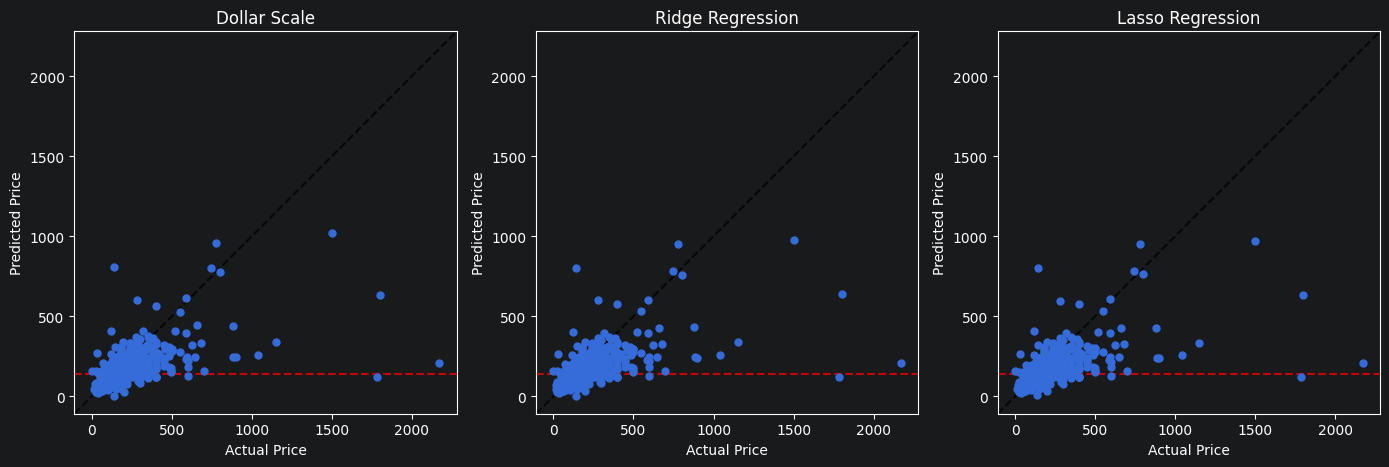

LR Results:
R2: 0.430	RMSE: 100.653	MAE: 40.999
Ridge Results:
R2: 0.428	RMSE: 100.839	MAE: 40.972
Lasso Results:
R2: 0.428	RMSE: 100.892	MAE: 40.920


In [22]:
# Comparison of optimised models

# Visualisation
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))

# Linear Regression
ax1.scatter(test_y, lr_pred_scaled, s=25, zorder=10)
lims = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),  # min of both axes
    np.max([ax1.get_xlim(), ax1.get_ylim()]),  # max of both axes
]
ax1.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax1.plot(lims, [np.mean(test_y),]*2, 'r--', alpha=0.75, zorder=0)
ax1.set_aspect('equal')
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.set_title('Dollar Scale')

# Ridge Regression
ax2.scatter(test_y, ridge_pred, s=25, zorder=10)
lims = [
    np.min([ax2.get_xlim(), ax2.get_ylim()]),
    np.max([ax2.get_xlim(), ax2.get_ylim()])
]
ax2.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax2.plot(lims, [np.mean(train_y),]*2, 'r--', alpha=0.75, zorder=0)
ax2.set_aspect('equal')
ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_xlabel('Actual Price')
ax2.set_ylabel('Predicted Price')
ax2.set_title('Ridge Regression')

# Lasso Regression
ax3.scatter(test_y, lasso_pred, s=25, zorder=10)
lims = [
    np.min([ax3.get_xlim(), ax3.get_ylim()]),
    np.max([ax3.get_xlim(), ax3.get_ylim()])
]
ax3.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax3.plot(lims, [np.mean(train_y),]*2, 'r--', alpha=0.75, zorder=0)
ax3.set_aspect('equal')
ax3.set_xlim(lims)
ax3.set_ylim(lims)
ax3.set_xlabel('Actual Price')
ax3.set_ylabel('Predicted Price')
ax3.set_title('Lasso Regression')

plt.tight_layout()
plt.show()

print("LR Results:")
print(f"R2: {r2_scaled:.3f}\tRMSE: {rmse_scaled:.3f}\tMAE: {mae_scaled:.3f}")
print("Ridge Results:")
print(f"R2: {r2_ridge:.3f}\tRMSE: {rmse_ridge:.3f}\tMAE: {mae_ridge:.3f}")
print('Lasso Results:')
print(f"R2: {r2_lasso:.3f}\tRMSE: {rmse_lasso:.3f}\tMAE: {mae_lasso:.3f}")

**Notes**
- Overall, very similar looking graphs. From the looks of it, the only discernible difference between them is that lasso fans out a little more and trends a bit closer to the mean line at the ~(500, 300) area

In [23]:
# Dataframe of all coefficients for the three models

coef_df = pd.DataFrame({'LR': lr_scaled_l.coef_, 'Ridge': ridge.coef_, 'Lasso': lasso.coef_}, index=train_x.columns)
print("Coefficient weights, sorted by LR magnitude:")
print(coef_df.sort_values('LR', key=abs, ascending=False).round(5)) # abs to judge magnitude, not just increase
print()
print(f"Number of features removed by Lasso: {(lasso.coef_ == 0).sum()} / {len(lasso.coef_)}")

Coefficient weights, sorted by LR magnitude:
                                     LR    Ridge    Lasso
bedrooms                        0.16011  0.15544  0.15797
room_type_Entire home/apt       0.13663  0.13621  0.25926
room_type_Private room         -0.12035 -0.12002 -0.00000
accommodates                    0.11465  0.11075  0.10858
city_Yarra Ranges               0.09031  0.07582  0.09273
room_type_Shared room          -0.07894 -0.07851 -0.05198
bathrooms                       0.06742  0.06764  0.06690
city_Wyndham                   -0.05669 -0.04999 -0.03090
city_Darebin                   -0.04115 -0.03981 -0.01648
city_Melbourne                  0.04007  0.04398  0.10596
longitude                      -0.03860 -0.01731 -0.00505
city_Maribyrnong               -0.03695 -0.03347 -0.01291
city_Moreland                  -0.03372 -0.03118 -0.00320
number_of_reviews              -0.03291 -0.03229 -0.03119
city_Hume                      -0.03180 -0.02891 -0.01478
city_Brimbank              

**Notes**
- LR and Ridge are very similar overall
- For the most part, the three models agree on the major features, but lasso has some big swings (eg. Melbourne's weighting)
- Lasso removed 6 features: private room, longitude, latitude, minimum nights, hobsons bay, and frankston
- No coefficient has a very high weight, so Ridge and Lasso could have unintentional negative effects on the predictions. Therefore, regular Linear Regression will be used

# 5: Final predictions

In [24]:
# Save final predictions to CSV

final_model = LinearRegression().fit(train_x_scaled, train_y_log)
unk_pred = np.expm1(final_model.predict(unk_scaled))
unk_pred = np.maximum(unk_pred, 0)
pd.DataFrame({'price': unk_pred}).to_csv('s3787701_predictions.csv', index=False)
print(f"Shape: {unk_pred.shape}, Mean: ${unk_pred.mean():.1f}, Min: ${unk_pred.min():.1f}, Max: ${unk_pred.max():.2f}")

Shape: (8585,), Mean: $130.1, Min: $0.0, Max: $18250.8


**Notes**
- Error values (0 price) are predicted to be slightly below 0, so these values are replaced by 0
- Insane max, and negative min are a product of the outliers, and fitting training the data on a more accurate training set. Strange outliers and errors from the data are handled poorly, but most of the values are more solid